<a href="https://colab.research.google.com/github/Kishore261/ECOMMERCE-BAKINGO-DATA-ANALYSIS/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***CAPESTONE PROJECT - DATA ANALYTICS***
---

## WEBSCRAPING  ECOMMERCE WEBSITE=**BAKINGO**(CAKES HUT)

Objective:
 To scarpe a product data from legal ecommerce website ,to scarpe its name,price,rating and reviews

BAKINGO:
1.Bakingo is a live Indian e-commerce platform that sells bakery products online.
2.Bakingo product pages provide:

*  Product Name
     * Price
     * Ratings
     * Number of Reviews
     * Product Category List item


“This allowed me to collect all mandatory attributes specified in the project rubric.”

In [ ]:
pip install requests BeautifulSoup4

In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
headers = {"User-Agent": "Mozilla/5.0"}
category_url = "https://www.bakingo.com/cakes"

In [ ]:
res = requests.get(category_url, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")

In [ ]:
product_links = []

for a in soup.select("a[href*='/p/']"):
    link = a.get("href")
    if link.startswith("/"):
        link = "https://www.bakingo.com" + link
    product_links.append(link)

product_links = list(set(product_links))  # remove duplicates
print("Total products:", len(product_links))
print(product_links[:15])


Total products: 34
['https://www.bakingo.com/p/cake/chocolicious-marble-cake-cake2615choc', 'https://www.bakingo.com/p/cake/floral-swirls-ribbon-cake-cake5306ribbon', 'https://www.bakingo.com/p/cake/snicker-chocolate-cake0028choc', 'https://www.bakingo.com/p/cake/lavender-blush-ribbon-cake-cake5305ribbon', 'https://www.bakingo.com/p/cake/creamy-pineapple-crown-cake-cake5279pine', 'https://www.bakingo.com/p/cake/viscous-blueberry-cheesecake-cake2859blue', 'https://www.bakingo.com/p/cake/ferrero-rocher-cake0013exot', 'https://www.bakingo.com/p/bakery-baskets/assorted-desserts-box-hamp4496assorted', 'https://www.bakingo.com/p/cake/kitkat-drip-cake-cake5330kikat', 'https://www.bakingo.com/p/cake/oreo-chocolate-drip-cake-cake3968choc', 'https://www.bakingo.com/p/cake/butterscotch-cake0003butt', 'https://www.bakingo.com/p/cake/pastel-wrap-ribbon-cake-cake5304ribbon', 'https://www.bakingo.com/p/cake/black-n-white-ribbon-cake-cake5307ribbon', 'https://www.bakingo.com/p/cupcake/assorted-cup-cak

In [ ]:
cakes = []

In [ ]:
for link in product_links[:10]:   # limit for testing
    r = requests.get(link, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    name_tag = soup.find("h1")
    price_tag = soup.select_one("span.currentPrice, span.selling-price")
    rating_tag = soup.select_one("span.actual-rating")
    review_tag = soup.select_one("span.listing-reviews")

    cake = {
        "Product Name": name_tag.get_text(strip=True) if name_tag else None,
        "Price": price_tag.get_text(strip=True) if price_tag else None,
        "Rating": rating_tag.get_text(strip=True) if rating_tag else None,
        "Number of Reviews": review_tag.get_text(strip=True) if review_tag else None,
        "Category": "Cakes"
    }

    cakes.append(cake)


In [ ]:
for c in cakes:
    print(c)

{'Product Name': 'Cherry Chocochip Chocolate Cake', 'Price': '549', 'Rating': '4.9', 'Number of Reviews': '(454Reviews)', 'Category': 'Cakes'}
{'Product Name': 'Floral Swirls Ribbon Cake', 'Price': '1649', 'Rating': '5', 'Number of Reviews': '(2Reviews)', 'Category': 'Cakes'}
{'Product Name': 'Chocolate Loaded Glazed Cake', 'Price': '649', 'Rating': '4.9', 'Number of Reviews': '(988Reviews)', 'Category': 'Cakes'}
{'Product Name': 'Lavender Blush Ribbon Cake', 'Price': '1649', 'Rating': '4.5', 'Number of Reviews': '(2Reviews)', 'Category': 'Cakes'}
{'Product Name': 'Creamy Pineapple Crown Cake', 'Price': '529', 'Rating': '4.9', 'Number of Reviews': '(13Reviews)', 'Category': 'Cakes'}
{'Product Name': 'Blueberry Cheesecake', 'Price': '779', 'Rating': '4.9', 'Number of Reviews': '(719Reviews)', 'Category': 'Cakes'}
{'Product Name': 'Ferrero Infused Celebration Cake', 'Price': '779', 'Rating': '4.9', 'Number of Reviews': '(590Reviews)', 'Category': 'Cakes'}
{'Product Name': 'Assorted Pastr

In [ ]:
import pandas as pd

df=pd.DataFrame(cakes)
df.to_csv("Bakingo_cakes_choco.csv",index=False)


Data Heading #top

In [ ]:
df.head()

,Product Name,Price,Rating,Number of Reviews,Category
0,Cherry Chocochip Chocolate Cake,549,4.9,(454Reviews),Cakes
1,Floral Swirls Ribbon Cake,1649,5,(2Reviews),Cakes
2,Chocolate Loaded Glazed Cake,649,4.9,(988Reviews),Cakes
3,Lavender Blush Ribbon Cake,1649,4.5,(2Reviews),Cakes
4,Creamy Pineapple Crown Cake,529,4.9,(13Reviews),Cakes


In [ ]:
df.tail()

,Product Name,Price,Rating,Number of Reviews,Category
5,Blueberry Cheesecake,779,4.9,(719Reviews),Cakes
6,Ferrero Infused Celebration Cake,779,4.9,(590Reviews),Cakes
7,Assorted Pastry Box,199-,4.9,(91Reviews),Cakes
8,KitKat Drip Cake,549,4.8,(12Reviews),Cakes
9,Oreo Chocolate Cake,1389,4.9,(30Reviews),Cakes


Some products did not display ratings or reviews at the time of scraping. These missing values were retained as NULL to preserve data integrity

In [ ]:
df.isnull().sum()

,0
Product Name,0
Price,0
Rating,0
Number of Reviews,0
Category,0


In [ ]:
import re

df['Price'] = df['Price'].astype(str)

df['Price'] = df['Price'].apply(
    lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else None
)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product Name       10 non-null     object
 1   Price              10 non-null     int64 
 2   Rating             10 non-null     object
 3   Number of Reviews  10 non-null     object
 4   Category           10 non-null     object
dtypes: int64(1), object(4)
memory usage: 532.0+ bytes


In [ ]:
df['Number of Reviews'] = df['Number of Reviews'].astype(str)

df['Number of Reviews'] = df['Number of Reviews'].apply(
    lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0
)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product Name       10 non-null     object
 1   Price              10 non-null     int64 
 2   Rating             10 non-null     object
 3   Number of Reviews  10 non-null     int64 
 4   Category           10 non-null     object
dtypes: int64(2), object(3)
memory usage: 532.0+ bytes


In [ ]:
df.head()

,Product Name,Price,Rating,Number of Reviews,Category
0,Cherry Chocochip Chocolate Cake,549,4.9,454,Cakes
1,Floral Swirls Ribbon Cake,1649,5,2,Cakes
2,Chocolate Loaded Glazed Cake,649,4.9,988,Cakes
3,Lavender Blush Ribbon Cake,1649,4.5,2,Cakes
4,Creamy Pineapple Crown Cake,529,4.9,13,Cakes


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,Product Name,Price,Rating,Number of Reviews,Category
0,Cherry Chocochip Chocolate Cake,549,4.9,454,Cakes
1,Floral Swirls Ribbon Cake,1649,5,2,Cakes
2,Chocolate Loaded Glazed Cake,649,4.9,988,Cakes
3,Lavender Blush Ribbon Cake,1649,4.5,2,Cakes
4,Creamy Pineapple Crown Cake,529,4.9,13,Cakes


In [ ]:
df.describe()

,Price,Number of Reviews
count,10.000000,10.000000
mean,872.000000,290.100000
std,507.828711,367.460187
min,199.000000,2.000000
25%,549.000000,12.250000
50%,714.000000,60.500000
75%,1236.500000,556.000000
max,1649.000000,988.000000


In [ ]:
df.dtypes


,0
Product Name,object
Price,int64
Rating,object
Number of Reviews,int64
Category,object


In [ ]:
df['Rating'] = df['Rating'].astype(str)

df['Rating'] = df['Rating'].apply(
    lambda x: float(x) if x.replace('.', '', 1).isdigit() else None
)


In [ ]:
df.dtypes


,0
Product Name,object
Price,int64
Rating,float64
Number of Reviews,int64
Category,object


In [ ]:
df

,Product Name,Price,Rating,Number of Reviews,Category
0,Cherry Chocochip Chocolate Cake,549,4.9,454,Cakes
1,Floral Swirls Ribbon Cake,1649,5.0,2,Cakes
2,Chocolate Loaded Glazed Cake,649,4.9,988,Cakes
3,Lavender Blush Ribbon Cake,1649,4.5,2,Cakes
4,Creamy Pineapple Crown Cake,529,4.9,13,Cakes
5,Blueberry Cheesecake,779,4.9,719,Cakes
6,Ferrero Infused Celebration Cake,779,4.9,590,Cakes
7,Assorted Pastry Box,199,4.9,91,Cakes
8,KitKat Drip Cake,549,4.8,12,Cakes
9,Oreo Chocolate Cake,1389,4.9,30,Cakes


In [ ]:
df.groupby("Category")["Price"].mean()


,Price
Category,
Cakes,872.0


In [ ]:
df.groupby("Category")["Number of Reviews"].sum()


,Number of Reviews
Category,
Cakes,2901


In [ ]:
df.groupby("Category")["Rating"].sum()


,Rating
Category,
Cakes,48.6


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

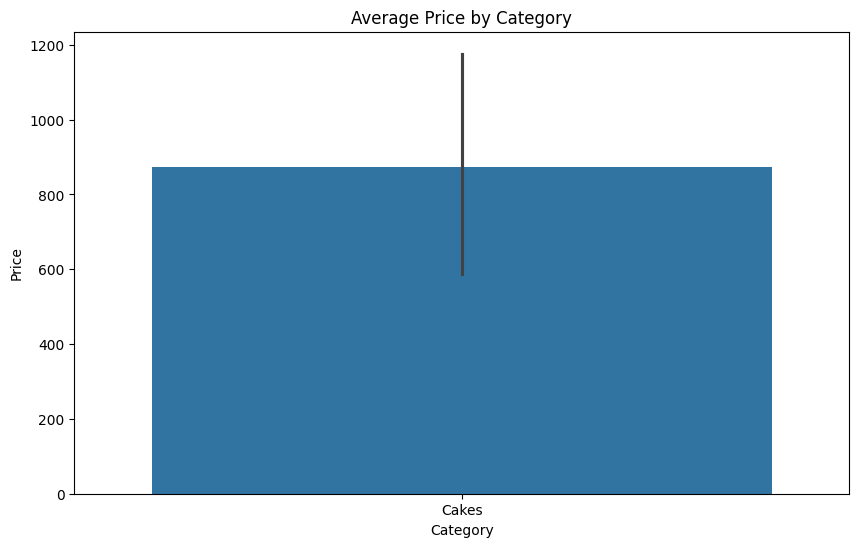

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Category',y='Price',data=df)
plt.title("Average Price by Category")
plt.show()

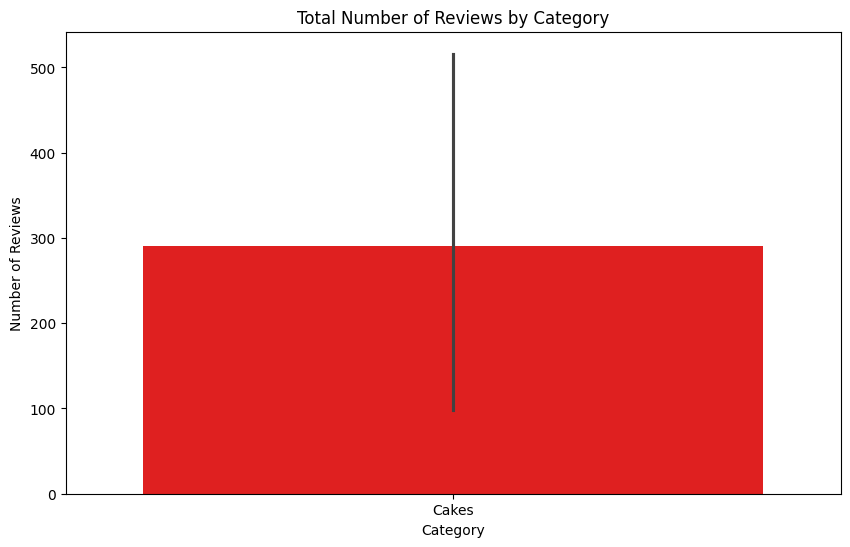

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Category',y='Number of Reviews',color='Red',data=df)
plt.title("Total Number of Reviews by Category")
plt.show()


In [ ]:
df['Rating'].mean()
df['Rating'].max()
df['Rating'].value_counts()


,count
Rating,
4.9,7
5.0,1
4.5,1
4.8,1


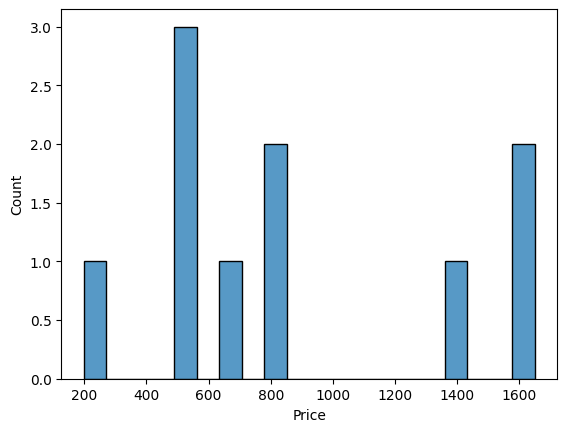

In [ ]:
sns.histplot(df['Price'], bins=20)
plt.show()


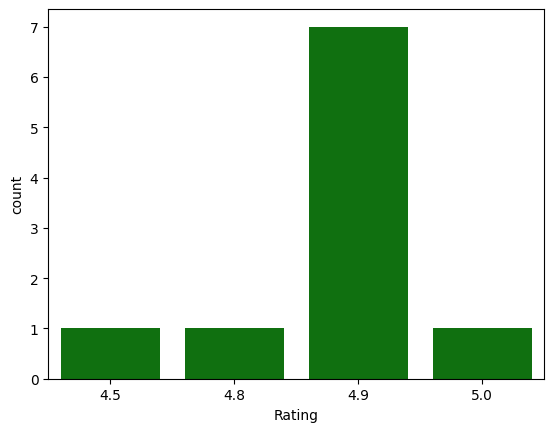

In [ ]:
sns.countplot(x=df['Rating'],color='Green')
plt.show()


CORRELATION ANALYSIS

In [ ]:
correlation=df[['Price','Rating','Number of Reviews']].corr()
correlation

,Price,Rating,Number of Reviews
Price,1.000000,-0.325464,-0.321331
Rating,-0.325464,1.000000,0.255897
Number of Reviews,-0.321331,0.255897,1.000000


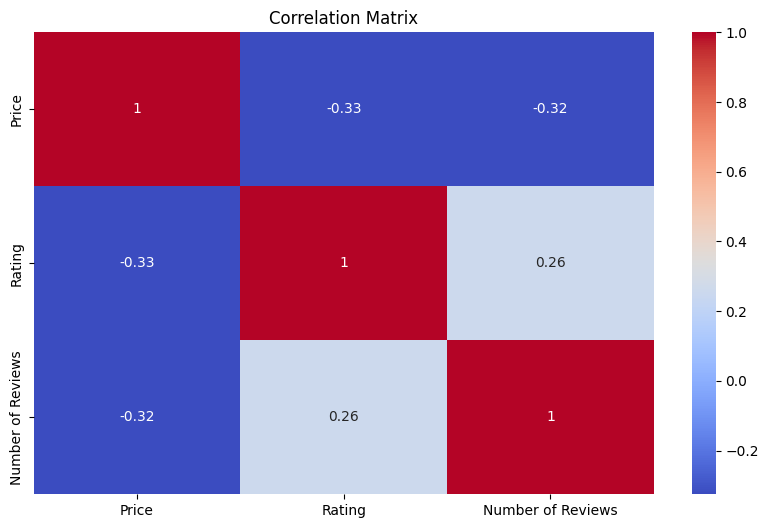

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Hypothesis testing is used to check whether a relationship or difference seen in data is real (statistically significant) or just happened by chance.

H₀: Price and Rating are not related
H₁: Price and Rating are related

In [ ]:
from scipy.stats import pearsonr

pearsonr(df['Price'], df['Rating'])


PearsonRResult(statistic=np.float64(-0.32546424053667355), pvalue=np.float64(0.3587897958153692))

statistics=0.27 shows Weak positive correlation
1.  when Price gets  increases, rating slightly increases,but relationship is  weak.

2.   p < 0.05 =statistically significant,p ≥ 0.05 = not statistically significant

so 0.478 >0.05 so its not Staistically Significant




Hypothesis Decision

H₀: Price and Rating are NOT related

H₁: Price and Rating are related

Decision:

Fail to reject Null Hypothesis (H₀)

In [ ]:
# cleaned dataset csv
df.to_csv("Bakingo_products_cleaned.csv",index=False)



Although there is a weak positive correlation between product price and customer rating, the relationship is not statistically significant (p > 0.05). Therefore, price does not have a meaningful impact on ratings in this dataset.

From **Bakingo e-commerce perspective:**

Customers do not rate products higher just because they are expensive

Rating depends more on:

Taste

Quality

Delivery

Customer experience


